# Part 3: Evolutionary Search NAS

## 이 노트북에서 다루는 내용
1. Evolutionary Search 전략의 원리
2. Tournament Selection + Mutation 기반 진화적 탐색
3. 세대별 진화 과정 추적
4. Random Search와 비교 분석

## Evolutionary NAS 핵심 개념

**Evolutionary Search**: 유전 알고리즘을 아키텍처 탐색에 적용

### 진화 과정
1. **초기 인구(Population)** 생성 및 평가
2. 각 세대(Generation)마다:
   - **Tournament Selection**: k개 중 가장 좋은 아키텍처 선택
   - **Mutation**: 선택된 아키텍처의 파라미터 하나를 랜덤 변경
   - 자식 아키텍처 학습 및 평가
   - **엘리트(상위 N개)** 유지 + 새 자식으로 인구 교체

### Evolutionary vs Random Search
| 특성 | Random Search | Evolutionary Search |
|------|--------------|--------------------|
| 탐색 이력 활용 | 없음 | 좋은 아키텍처 근처 집중 |
| 구현 복잡도 | 매우 간단 | 중간 |
| 탐색 효율 | 보통 | 더 효율적 (exploitation) |

## [1] 환경 설정 및 데이터 로드

In [1]:
import os
import time
import random
import copy

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import (
    CNN, FlexibleCNN, SEARCH_SPACE,
    sample_architecture, architecture_to_string, mutate_architecture
)

# 환경 설정
def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
print(f"Using device: {DEVICE}")

# 하이퍼파라미터
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_CLASSES = 10

# NAS 전용
SEARCH_EPOCHS = 5
FULL_EPOCHS = 10
POPULATION_SIZE = 10
NUM_GENERATIONS = 5
TOURNAMENT_SIZE = 3
ELITE_SIZE = 2

SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)

Using device: cuda


In [2]:
# 데이터 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"학습 데이터: {len(train_dataset):,} 샘플")
print(f"테스트 데이터: {len(test_dataset):,} 샘플")

학습 데이터: 50,000 샘플
테스트 데이터: 10,000 샘플


## [2] 학습/평가 함수 및 Evolutionary 핵심 함수

In [3]:
def train(model, train_loader, epochs, learning_rate, device, verbose=True):
    """Cross-Entropy 학습"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()

    epoch_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        if verbose:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

    return epoch_losses


def test(model, test_loader, device):
    """모델 평가"""
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def train_and_evaluate(arch, train_loader, test_loader, epochs, learning_rate, device, seed=42):
    """하나의 아키텍처를 학습하고 평가"""
    torch.manual_seed(seed)
    model = FlexibleCNN(arch, num_classes=NUM_CLASSES)
    params = count_parameters(model)
    start_time = time.time()
    train_losses = train(model, train_loader, epochs, learning_rate, device, verbose=False)
    train_time = time.time() - start_time
    accuracy = test(model, test_loader, device)
    return {
        'arch': arch, 'accuracy': accuracy, 'params': params,
        'train_losses': train_losses, 'train_time': train_time
    }


def tournament_selection(population, fitnesses, tournament_size=3):
    """토너먼트 선택: k개 중 가장 적합도가 높은 개체 선택"""
    indices = random.sample(range(len(population)), min(tournament_size, len(population)))
    best_idx = max(indices, key=lambda i: fitnesses[i])
    return copy.deepcopy(population[best_idx])

## [3] Baseline 준비

In [4]:
torch.manual_seed(SEED)
baseline_model = CNN(num_classes=NUM_CLASSES).to(DEVICE)
baseline_params = count_parameters(baseline_model)
print(f"Baseline 파라미터: {baseline_params:,}")

print("\nBaseline 학습 중...")
train(baseline_model, train_loader, FULL_EPOCHS, LEARNING_RATE, DEVICE)
baseline_accuracy = test(baseline_model, test_loader, DEVICE)
print(f"Baseline 정확도: {baseline_accuracy:.2f}%")

Baseline 파라미터: 1,186,986

Baseline 학습 중...
Epoch 1/10, Loss: 1.3422
Epoch 2/10, Loss: 0.8709
Epoch 3/10, Loss: 0.6855
Epoch 4/10, Loss: 0.5462
Epoch 5/10, Loss: 0.4350
Epoch 6/10, Loss: 0.3331
Epoch 7/10, Loss: 0.2431
Epoch 8/10, Loss: 0.1872
Epoch 9/10, Loss: 0.1485
Epoch 10/10, Loss: 0.1347
Baseline 정확도: 75.01%


## [4] Evolutionary Search 실행

### 설정
- 인구 크기: 10
- 세대 수: 5
- 토너먼트 크기: 3
- 엘리트 유지: 2

In [5]:
num_children_per_gen = POPULATION_SIZE - ELITE_SIZE
total_evaluations = POPULATION_SIZE + NUM_GENERATIONS * num_children_per_gen
print(f"예상 총 평가 횟수: {POPULATION_SIZE} + {NUM_GENERATIONS} x {num_children_per_gen} = {total_evaluations}")
print(f"축소 학습: {SEARCH_EPOCHS} epochs per architecture")
print()

예상 총 평가 횟수: 10 + 5 x 8 = 50
축소 학습: 5 epochs per architecture



In [6]:
# 초기 인구 생성 및 평가
all_evaluated = []
generation_history = []

population = []
fitnesses = []

print(f"[초기 인구 생성] {POPULATION_SIZE}개 아키텍처")
print("-" * 60)

for i in range(POPULATION_SIZE):
    arch = sample_architecture(seed=SEED + i)
    result = train_and_evaluate(
        arch, train_loader, test_loader,
        SEARCH_EPOCHS, LEARNING_RATE, DEVICE, seed=SEED
    )
    population.append(arch)
    fitnesses.append(result['accuracy'])
    all_evaluated.append(result)

    print(f"  [{i+1}/{POPULATION_SIZE}] {architecture_to_string(arch)} | "
          f"Acc: {result['accuracy']:.2f}% | Params: {result['params']:,}")

best_idx = np.argmax(fitnesses)
generation_history.append({
    'generation': 0,
    'best_accuracy': fitnesses[best_idx],
    'mean_accuracy': float(np.mean(fitnesses)),
    'num_evaluated': len(all_evaluated)
})
print(f"\n세대 0 | Best: {fitnesses[best_idx]:.2f}% | Mean: {np.mean(fitnesses):.2f}%")

[초기 인구 생성] 10개 아키텍처
------------------------------------------------------------
  [1/10] F[16-16-64-32]_K[3-3-3-3]_FC1024 | Acc: 73.16% | Params: 566,074
  [2/10] F[16-64-32-128]_K[5-3-5-5]_FC128 | Acc: 76.02% | Params: 427,818
  [3/10] F[128-16-32-128]_K[3-5-3-3]_FC128 | Acc: 73.06% | Params: 359,994
  [4/10] F[64-128-128-64]_K[3-5-5-3]_FC128 | Acc: 75.18% | Params: 822,730
  [5/10] F[16-128-16-32]_K[3-3-3-3]_FC512 | Acc: 72.66% | Params: 309,882
  [6/10] F[64-16-128-128]_K[5-5-5-5]_FC128 | Acc: 74.76% | Params: 755,098
  [7/10] F[64-32-64-32]_K[5-3-3-3]_FC1024 | Acc: 75.61% | Params: 595,850
  [8/10] F[16-64-128-16]_K[5-3-3-5]_FC256 | Acc: 73.61% | Params: 203,930
  [9/10] F[128-64-64-32]_K[5-5-3-5]_FC256 | Acc: 75.14% | Params: 436,650
  [10/10] F[32-32-32-32]_K[5-5-5-5]_FC512 | Acc: 74.30% | Params: 347,114

세대 0 | Best: 76.02% | Mean: 74.35%


In [7]:
# 세대별 진화
total_start = time.time()

for gen in range(1, NUM_GENERATIONS + 1):
    print(f"\n[세대 {gen}/{NUM_GENERATIONS}]")
    print("-" * 60)

    # 엘리트 선택
    sorted_indices = sorted(range(len(fitnesses)),
                             key=lambda i: fitnesses[i], reverse=True)
    elite_indices = sorted_indices[:ELITE_SIZE]

    new_population = [copy.deepcopy(population[i]) for i in elite_indices]
    new_fitnesses = [fitnesses[i] for i in elite_indices]

    print(f"  엘리트 {ELITE_SIZE}개 유지:")
    for idx in elite_indices:
        print(f"    - {architecture_to_string(population[idx])} | Acc: {fitnesses[idx]:.2f}%")

    # 자식 생성
    num_children = POPULATION_SIZE - ELITE_SIZE
    print(f"\n  자식 {num_children}개 생성:")

    for i in range(num_children):
        parent = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
        child = mutate_architecture(parent)

        result = train_and_evaluate(
            child, train_loader, test_loader,
            SEARCH_EPOCHS, LEARNING_RATE, DEVICE, seed=SEED
        )
        new_population.append(child)
        new_fitnesses.append(result['accuracy'])
        all_evaluated.append(result)

        print(f"    [{i+1}/{num_children}] "
              f"Parent: {architecture_to_string(parent)} -> "
              f"Child: {architecture_to_string(child)} | "
              f"Acc: {result['accuracy']:.2f}%")

    population = new_population
    fitnesses = new_fitnesses

    best_idx = np.argmax(fitnesses)
    generation_history.append({
        'generation': gen,
        'best_accuracy': fitnesses[best_idx],
        'mean_accuracy': float(np.mean(fitnesses)),
        'num_evaluated': len(all_evaluated)
    })
    print(f"\n  세대 {gen} | Best: {fitnesses[best_idx]:.2f}% | "
          f"Mean: {np.mean(fitnesses):.2f}% | 총 평가: {len(all_evaluated)}개")

search_time = time.time() - total_start
overall_best = max(all_evaluated, key=lambda x: x['accuracy'])
print(f"\n총 탐색 시간: {search_time:.1f}s")
print(f"Best: {architecture_to_string(overall_best['arch'])} | Acc: {overall_best['accuracy']:.2f}%")


[세대 1/5]
------------------------------------------------------------
  엘리트 2개 유지:
    - F[16-64-32-128]_K[5-3-5-5]_FC128 | Acc: 76.02%
    - F[64-32-64-32]_K[5-3-3-3]_FC1024 | Acc: 75.61%

  자식 8개 생성:
    [1/8] Parent: F[64-32-64-32]_K[5-3-3-3]_FC1024 -> Child: F[16-32-64-32]_K[5-3-3-3]_FC1024 | Acc: 73.17%
    [2/8] Parent: F[128-64-64-32]_K[5-5-3-5]_FC256 -> Child: F[32-64-64-32]_K[5-5-3-5]_FC256 | Acc: 74.19%
    [3/8] Parent: F[64-16-128-128]_K[5-5-5-5]_FC128 -> Child: F[64-16-128-128]_K[5-3-5-5]_FC128 | Acc: 76.06%
    [4/8] Parent: F[64-128-128-64]_K[3-5-5-3]_FC128 -> Child: F[64-128-32-64]_K[3-5-5-3]_FC128 | Acc: 73.95%
    [5/8] Parent: F[16-64-32-128]_K[5-3-5-5]_FC128 -> Child: F[16-16-32-128]_K[5-3-5-5]_FC128 | Acc: 74.00%
    [6/8] Parent: F[128-64-64-32]_K[5-5-3-5]_FC256 -> Child: F[128-64-64-32]_K[5-5-5-5]_FC256 | Acc: 75.34%
    [7/8] Parent: F[16-64-32-128]_K[5-3-5-5]_FC128 -> Child: F[16-64-32-128]_K[5-3-5-3]_FC128 | Acc: 74.32%
    [8/8] Parent: F[64-16-128-128]_K[5-

## [5] Best 아키텍처 전체 학습

In [8]:
best_arch = overall_best['arch']
print(f"Best 아키텍처: {architecture_to_string(best_arch)}")
print(f"축소 학습 정확도: {overall_best['accuracy']:.2f}%")
print(f"파라미터 수: {overall_best['params']:,}")

print(f"\n전체 학습 ({FULL_EPOCHS} epochs):")
torch.manual_seed(SEED)
best_model = FlexibleCNN(best_arch, num_classes=NUM_CLASSES)
train(best_model, train_loader, FULL_EPOCHS, LEARNING_RATE, DEVICE)
best_full_accuracy = test(best_model, test_loader, DEVICE)
print(f"전체 학습 정확도: {best_full_accuracy:.2f}%")

Best 아키텍처: F[128-64-64-128]_K[3-3-5-5]_FC1024
축소 학습 정확도: 78.80%
파라미터 수: 2,493,194

전체 학습 (10 epochs):
Epoch 1/10, Loss: 1.3931
Epoch 2/10, Loss: 0.8988
Epoch 3/10, Loss: 0.7009
Epoch 4/10, Loss: 0.5644
Epoch 5/10, Loss: 0.4492
Epoch 6/10, Loss: 0.3519
Epoch 7/10, Loss: 0.2585
Epoch 8/10, Loss: 0.1881
Epoch 9/10, Loss: 0.1596
Epoch 10/10, Loss: 0.1182
전체 학습 정확도: 78.23%


## [6] 결과 시각화

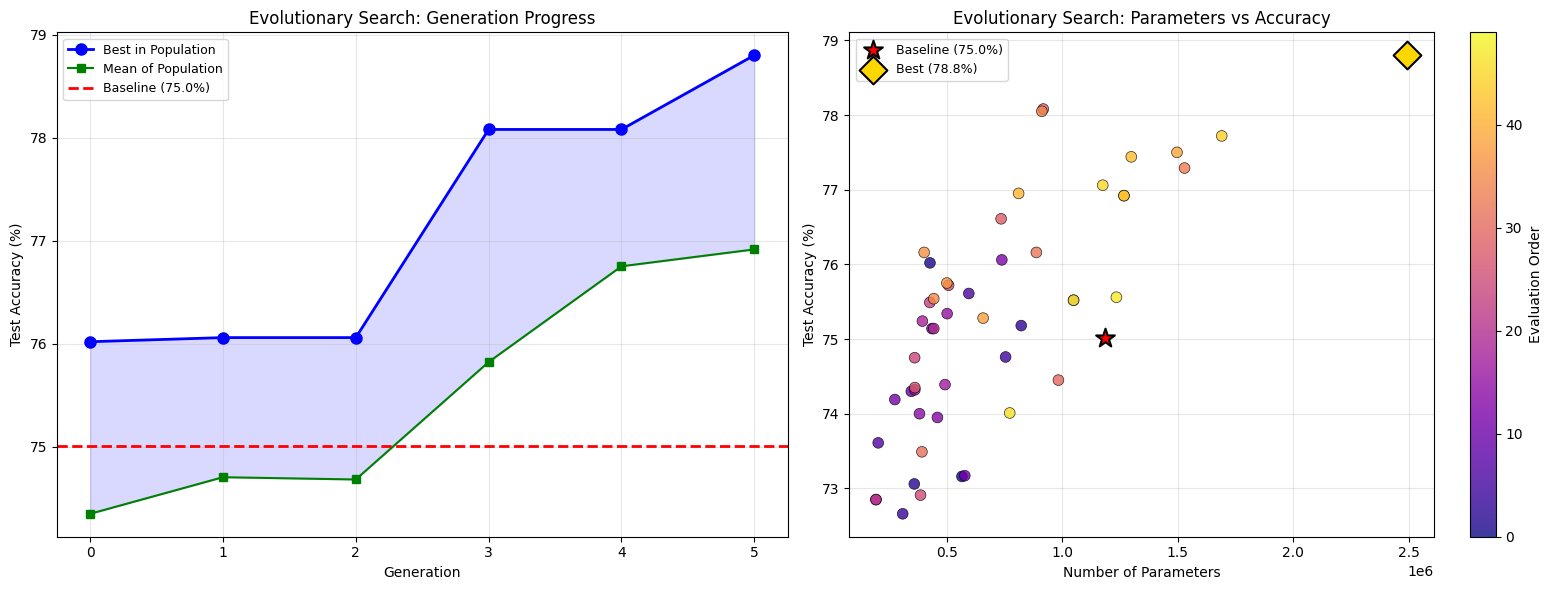

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: 세대별 정확도 추이 ---
ax1 = axes[0]
generations = [g['generation'] for g in generation_history]
best_accs = [g['best_accuracy'] for g in generation_history]
mean_accs = [g['mean_accuracy'] for g in generation_history]

ax1.plot(generations, best_accs, 'b-o', markersize=8, linewidth=2, label='Best in Population')
ax1.plot(generations, mean_accs, 'g-s', markersize=6, linewidth=1.5, label='Mean of Population')
ax1.axhline(y=baseline_accuracy, color='red', linestyle='--',
            linewidth=2, label=f'Baseline ({baseline_accuracy:.1f}%)')
ax1.fill_between(generations, mean_accs, best_accs, alpha=0.15, color='blue')

ax1.set_xlabel('Generation')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Evolutionary Search: Generation Progress')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(generations)

# --- Plot 2: 전체 평가 scatter ---
ax2 = axes[1]
accs = [r['accuracy'] for r in all_evaluated]
params = [r['params'] for r in all_evaluated]

scatter = ax2.scatter(params, accs, c=range(len(all_evaluated)),
                      cmap='plasma', s=60, edgecolors='black', linewidth=0.5, alpha=0.8, zorder=3)
plt.colorbar(scatter, ax=ax2, label='Evaluation Order')

ax2.scatter([baseline_params], [baseline_accuracy], c='red', s=200,
            marker='*', edgecolors='black', linewidth=1.5,
            zorder=4, label=f'Baseline ({baseline_accuracy:.1f}%)')
ax2.scatter([overall_best['params']], [overall_best['accuracy']], c='gold', s=200,
            marker='D', edgecolors='black', linewidth=1.5,
            zorder=4, label=f'Best ({overall_best["accuracy"]:.1f}%)')

ax2.set_xlabel('Number of Parameters')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Evolutionary Search: Parameters vs Accuracy')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 결과 요약

In [10]:
print("=" * 60)
print("결과 요약: Evolutionary Search vs Baseline")
print("=" * 60)
print(f"{'Method':<25} {'Accuracy':<15} {'Parameters':<15}")
print("-" * 55)
print(f"{'Baseline (Human)':<25} {baseline_accuracy:>10.2f}% {baseline_params:>12,}")
print(f"{'Evolutionary (축소)':<25} {overall_best['accuracy']:>10.2f}% {overall_best['params']:>12,}")
print(f"{'Evolutionary (전체)':<25} {best_full_accuracy:>10.2f}% {overall_best['params']:>12,}")
print("-" * 55)

acc_diff = best_full_accuracy - baseline_accuracy
param_ratio = overall_best['params'] / baseline_params * 100
print(f"\n정확도 차이: {acc_diff:+.2f}%")
print(f"파라미터 비율: {param_ratio:.1f}% (Baseline 대비)")
print(f"총 평가 횟수: {len(all_evaluated)}개")

print(f"\n[세대별 진화 요약]")
print(f"{'세대':<8} {'Best Acc':<12} {'Mean Acc':<12} {'총 평가':<10}")
print("-" * 42)
for g in generation_history:
    print(f"{g['generation']:<8} {g['best_accuracy']:>8.2f}% {g['mean_accuracy']:>9.2f}% {g['num_evaluated']:>8}")

결과 요약: Evolutionary Search vs Baseline
Method                    Accuracy        Parameters     
-------------------------------------------------------
Baseline (Human)               75.01%    1,186,986
Evolutionary (축소)              78.80%    2,493,194
Evolutionary (전체)              78.23%    2,493,194
-------------------------------------------------------

정확도 차이: +3.22%
파라미터 비율: 210.0% (Baseline 대비)
총 평가 횟수: 50개

[세대별 진화 요약]
세대       Best Acc     Mean Acc     총 평가      
------------------------------------------
0           76.02%     74.35%       10
1           76.06%     74.71%       18
2           76.06%     74.68%       26
3           78.08%     75.82%       34
4           78.08%     76.75%       42
5           78.80%     76.92%       50
